In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
print(x_train)

NameError: name 'x_train' is not defined

In [7]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [8]:
print(x_train.shape)

NameError: name 'x_train' is not defined

In [9]:
inputs = tf.keras.Input(shape=(28,28,1))

x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', name="conv1")(inputs)
x = tf.keras.layers.MaxPooling2D((2,2))(x)

x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', name="conv2")(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)

In [11]:
x

<KerasTensor shape=(None, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_6>

In [6]:
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

In [7]:
model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
model.fit(X_train, y_train, epochs=3, validation_data=(X_test, y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9045 - loss: 0.3212 - val_accuracy: 0.9827 - val_loss: 0.0544
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9840 - loss: 0.0518 - val_accuracy: 0.9871 - val_loss: 0.0378
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9896 - loss: 0.0347 - val_accuracy: 0.9900 - val_loss: 0.0320


# Create a feature map

In [10]:
layer_outputs = [model.get_layer("conv1").output,
                 model.get_layer("conv2").output]

In [11]:
layer_outputs

[<KerasTensor shape=(None, 26, 26, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>,
 <KerasTensor shape=(None, 11, 11, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>]

In [12]:
visual_model = tf.keras.Model(inputs=model.input, outputs=layer_outputs)

In [13]:
visual_model

<Functional name=functional_1, built=True>

# Random Image

In [14]:
img = X_test[0].reshape(1,28,28,1)

feature_maps = visual_model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


In [15]:
feature_maps

[array([[[[-0.        , -0.        , -0.        , ...,  0.03334076,
           -0.        , -0.        ],
          [-0.        , -0.        , -0.        , ...,  0.03334076,
           -0.        , -0.        ],
          [-0.        , -0.        , -0.        , ...,  0.03334076,
           -0.        , -0.        ],
          ...,
          [-0.        , -0.        , -0.        , ...,  0.03334076,
           -0.        , -0.        ],
          [-0.        , -0.        , -0.        , ...,  0.03334076,
           -0.        , -0.        ],
          [-0.        , -0.        , -0.        , ...,  0.03334076,
           -0.        , -0.        ]],
 
         [[-0.        , -0.        , -0.        , ...,  0.03334076,
           -0.        , -0.        ],
          [-0.        , -0.        , -0.        , ...,  0.03334076,
           -0.        , -0.        ],
          [-0.        , -0.        , -0.        , ...,  0.03334076,
           -0.        , -0.        ],
          ...,
          [-0

# Plot Image

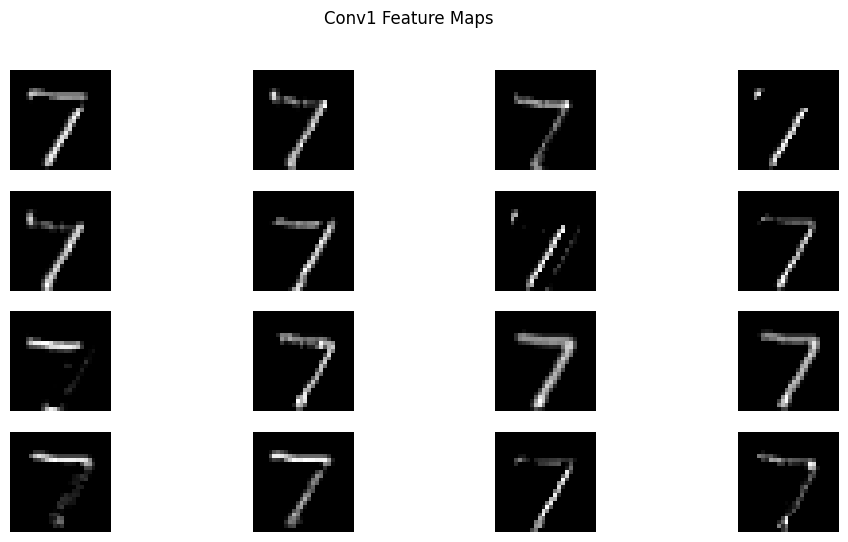

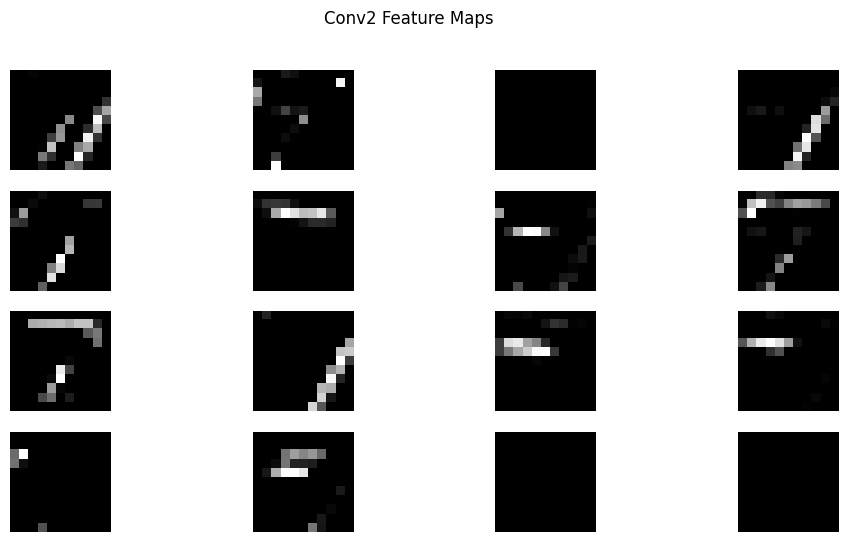

In [16]:
layer_names = ["Conv1", "Conv2"]

for layer_name, feature_map in zip(layer_names, feature_maps):

    num_filters = feature_map.shape[-1]

    plt.figure(figsize=(12,6))
    plt.suptitle(f"{layer_name} Feature Maps")

    for i in range(min(num_filters, 16)):
        plt.subplot(4,4,i+1)
        plt.imshow(feature_map[0,:,:,i], cmap='gray')
        plt.axis('off')

    plt.show()

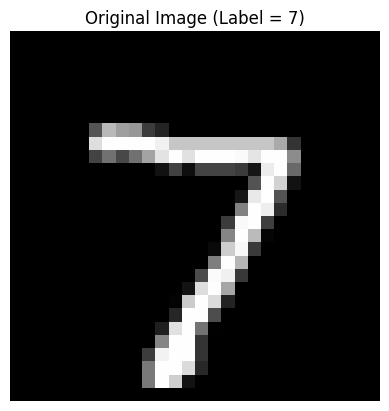

In [17]:
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Original Image (Label = {y_test[0]})")
plt.axis('off')
plt.show()